# Benchmarking OmniCloudMask Inference

This notebook measures how OmniCloudMask inference time scales with scene size across devices (CPU, CUDA, MPS) and data types (float32, float16). It:

1. Detects available devices and supported dtypes, and records a hardware fingerprint
2. Defines helper functions for scene generation, device synchronisation, and timing
3. Benchmarks each device/dtype/scene-size combination — warming up, searching for the optimal batch size, then timing over multiple runs
4. Plots inference time vs scene size
5. Exports results to JSON for use in documentation

In [1]:
import os
import platform
import time
from datetime import datetime, timezone

import numpy as np
import torch

import omnicloudmask
from omnicloudmask import predict_from_array

## 1. Detect available devices and dtypes

Automatically discovers which devices are present and which inference dtypes each supports. Reduced precision (`float16`) is only tested on GPU — PyTorch lacks efficient CPU kernels for those types.

Also builds a machine fingerprint (hardware name, OS, RAM, PyTorch version) for reproducibility. On macOS, the CPU and GPU (MPS) name is read from `sysctl` to get the actual chip name (e.g. `Apple M4 Pro`) rather than just the architecture.

In [2]:
import subprocess

devices: list[str] = ["cpu"]
if torch.cuda.is_available():
    devices.append("cuda")
if torch.backends.mps.is_available():
    devices.append("mps")

# Reduced precision is only beneficial on GPU — skip it for CPU.
# Only float16 is tested (not bfloat16) as they have equivalent throughput
# on modern GPUs and float16 has broader hardware support.
DTYPES: dict[str, list[torch.dtype]] = {}
for dev in devices:
    if dev == "cpu":
        DTYPES[dev] = [torch.float32]
    elif dev == "cuda":
        DTYPES[dev] = [torch.float32, torch.float16]
    elif dev == "mps":
        DTYPES[dev] = [torch.float32, torch.float16]
all_sizes = [
    50,
    100,
    200,
    300,
    400,
    500,
    750,
    1_000,
    2_000,
    2_236,
    3_000,
    3_162,
    5_000,
    7_071,
    10_000,
]
SCENE_SIZES: dict[str, list[int]] = {
    "cpu": all_sizes,
    "cuda": all_sizes,
    "mps": all_sizes,
}
BATCH_SIZES: dict[str, list[int]] = {
    "cpu": [1, 2, 4],
    "cuda": [1, 2, 4, 8, 16],
    "mps": [1, 2, 4, 8, 16],
}
# More repeats for small scenes where system jitter dominates
REPEATS_SMALL = 6  # scenes <= 500 px
REPEATS_LARGE = 3  # scenes > 500 px
BS_SEARCH_REPEATS = 3


def _sysctl(key: str) -> str:
    """Return the value of a sysctl key, or empty string on failure."""
    try:
        result = subprocess.run(
            ["sysctl", "-n", key], capture_output=True, text=True, timeout=5
        )
        return result.stdout.strip() if result.returncode == 0 else ""
    except Exception:
        return ""


def get_cpu_name() -> str:
    """Get CPU model name cross-platform."""
    if platform.system() == "Darwin":
        name = _sysctl("machdep.cpu.brand_string")
        if name:
            return name
    try:
        with open("/proc/cpuinfo") as f:
            for line in f:
                if line.startswith("model name"):
                    return line.split(":")[1].strip()
    except FileNotFoundError:
        pass
    return platform.processor() or "Unknown"


def get_mps_gpu_name() -> str:
    """Get Apple Silicon chip name for MPS GPU labelling."""
    name = _sysctl("machdep.cpu.brand_string")
    return f"{name} (MPS)" if name else "Apple MPS"


def get_ram_gb() -> float:
    """Get total system RAM in GB using stdlib only."""
    try:
        pages = os.sysconf("SC_PHYS_PAGES")
        page_size = os.sysconf("SC_PAGE_SIZE")
        return round(pages * page_size / (1024**3), 1)
    except (ValueError, OSError):
        return 0.0


# Machine fingerprint for reproducibility and cross-platform comparison
fingerprint: dict = {
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "omnicloudmask_version": omnicloudmask.__version__,
    "pytorch_version": torch.__version__,
    "os": f"{platform.system()} {platform.release()}",
    "python_version": platform.python_version(),
    "cpu": get_cpu_name(),
    "ram_gb": get_ram_gb(),
}
if torch.cuda.is_available():
    fingerprint["cuda_version"] = torch.version.cuda
    fingerprint["gpu"] = torch.cuda.get_device_name(0)
    fingerprint["gpu_memory_gb"] = round(
        torch.cuda.get_device_properties(0).total_memory / (1024**3), 1
    )
if torch.backends.mps.is_available():
    fingerprint["gpu"] = get_mps_gpu_name()

for k, v in fingerprint.items():
    print(f"{k:>22} : {v}")
print()
print(f"Devices         : {', '.join(devices)}")
for dev in devices:
    dtypes_str = ", ".join(str(d).split(".")[-1] for d in DTYPES[dev])
    print(f"  {dev:>5} dtypes  : {dtypes_str}")
    print(f"  {dev:>5} scenes  : {SCENE_SIZES[dev]}")
    print(f"  {dev:>5} batches : {BATCH_SIZES[dev]}")
print(f"Repeats         : {REPEATS_SMALL} (<=500px), {REPEATS_LARGE} (>500px)")
print(f"BS search runs  : {BS_SEARCH_REPEATS}")

             timestamp : 2026-03-28T07:26:02.990738+00:00
 omnicloudmask_version : 1.7.1
       pytorch_version : 2.10.0
                    os : Darwin 25.2.0
        python_version : 3.12.11
                   cpu : Apple M4 Pro
                ram_gb : 64.0
                   gpu : Apple M4 Pro (MPS)

Devices         : cpu, mps
    cpu dtypes  : float32
    cpu scenes  : [50, 100, 200, 300, 400, 500, 750, 1000, 2000, 2236, 3000, 3162, 5000, 7071, 10000]
    cpu batches : [1, 2, 4]
    mps dtypes  : float32, float16
    mps scenes  : [50, 100, 200, 300, 400, 500, 750, 1000, 2000, 2236, 3000, 3162, 5000, 7071, 10000]
    mps batches : [1, 2, 4, 8, 16]
Repeats         : 6 (<=500px), 3 (>500px)
BS search runs  : 3


## 2. Helper functions

- `make_scene` generates a synthetic `(3, H, W)` uint16 array (Red, Green, NIR) with a fixed seed for reproducibility
- `sync_device` ensures GPU work is complete before timing
- `timed_predict` runs a single inference call and returns wall-clock seconds. For scenes smaller than 1000 px the patch size is set to the scene size; larger scenes use the default 1000 px patches with 300 px overlap
- `find_optimal_batch_size` tries each candidate batch size for a given scene using the median of multiple runs, and returns the fastest one, stopping early on OOM

In [3]:
def make_scene(size: int) -> np.ndarray:
    """Synthetic (3, H, W) uint16 array — Red, Green, NIR.

    Uses a fixed seed so every scene has identical statistical properties,
    ensuring timing differences reflect compute cost, not data variation.
    """
    rng = np.random.default_rng(42)
    return rng.integers(100, 4000, size=(3, size, size), dtype=np.uint16)


def sync_device(device: str) -> None:
    """Block until all queued GPU work finishes, so timings are accurate."""
    if device == "cuda":
        torch.cuda.synchronize()
    elif device == "mps":
        torch.mps.synchronize()


def timed_predict(
    scene: np.ndarray,
    batch_size: int,
    device: str,
    dtype: torch.dtype,
) -> float:
    """Run a single prediction and return wall-clock seconds."""
    scene_size = scene.shape[-1]
    patch_size = min(scene_size, 1000)
    patch_overlap = 0 if scene_size <= 1000 else 300
    sync_device(device)
    t0 = time.perf_counter()
    predict_from_array(
        input_array=scene,
        patch_size=patch_size,
        patch_overlap=patch_overlap,
        batch_size=batch_size,
        inference_device=device,
        mosaic_device=device,
        inference_dtype=dtype,
    )
    sync_device(device)
    return time.perf_counter() - t0


def find_optimal_batch_size(
    scene: np.ndarray,
    device: str,
    dtype: torch.dtype,
) -> int:
    """Try each candidate batch size and return the fastest.

    Each batch size is warmed up before timing. The median of
    BS_SEARCH_REPEATS timed runs is used to reduce noise.
    """
    best_bs = 1
    best_time = float("inf")

    for bs in BATCH_SIZES[device]:
        try:
            # Warm up this batch size
            timed_predict(scene, batch_size=bs, device=device, dtype=dtype)
            # Median of multiple timed runs to reduce noise
            times = [
                timed_predict(scene, batch_size=bs, device=device, dtype=dtype)
                for _ in range(BS_SEARCH_REPEATS)
            ]
            t = float(np.median(times))
            if t < best_time:
                best_time = t
                best_bs = bs
        except RuntimeError as e:
            if (
                "out of memory" in str(e).lower()
                or "not enough memory" in str(e).lower()
            ):
                if device == "cuda":
                    torch.cuda.empty_cache()
                break
            raise
    return best_bs

## 3. Benchmark across scene sizes

For each device/dtype/scene-size combination: warm up, find the optimal batch size, then run timed repeats. Scenes are pre-generated so array creation time is excluded. Mean and standard deviation are reported along with the chosen batch size.

In [4]:
# Pre-generate all scenes so array creation isn't included in timings
all_sizes = sorted(set(s for sizes in SCENE_SIZES.values() for s in sizes))
scenes: dict[int, np.ndarray] = {size: make_scene(size) for size in all_sizes}
warmup_scene = make_scene(64)

# results[(device, dtype)] = list of (size, mean_s, std_s, bs)
results: dict[tuple[str, torch.dtype], list[tuple]] = {}

for device in devices:
    for dtype in DTYPES[device]:
        dtype_name = str(dtype).split(".")[-1]
        key = (device, dtype)

        # Warm up this device/dtype before any timing
        timed_predict(warmup_scene, batch_size=1, device=device, dtype=dtype)

        print(f"\n{device} / {dtype_name}")
        print(f"{'size':>10}  {'bs':>4}  {'reps':>4}  {'mean_s':>8}  {'std_s':>8}")
        print("-" * 46)

        config_results = []
        for size in SCENE_SIZES[device]:
            scene = scenes[size]
            repeats = REPEATS_SMALL if size <= 500 else REPEATS_LARGE

            # Only one patch when scene <= 1000 px, so bs=1
            if size <= 1000:
                bs = 1
            else:
                bs = find_optimal_batch_size(scene, device, dtype)

            # Warmup with chosen batch size, then time
            timed_predict(scene, batch_size=bs, device=device, dtype=dtype)

            times = []
            for _ in range(repeats):
                t = timed_predict(scene, batch_size=bs, device=device, dtype=dtype)
                times.append(t)
            mean_s = float(np.mean(times))
            std_s = float(np.std(times, ddof=1))
            config_results.append((size, mean_s, std_s, bs))
            print(f"{size:>10}  {bs:>4}  {repeats:>4}  {mean_s:>8.3f}  {std_s:>8.3f}")

        results[key] = config_results


cpu / float32
      size    bs  reps    mean_s     std_s
----------------------------------------------
        50     1     6     0.119     0.002
       100     1     6     0.144     0.002
       200     1     6     0.171     0.003
       300     1     6     0.205     0.006
       400     1     6     0.243     0.004
       500     1     6     0.323     0.009
       750     1     3     0.578     0.005
      1000     1     3     0.887     0.015
      2000     1     3     7.759     0.188
      2236     1     3     8.206     0.043
      3000     1     3    14.387     0.101
      3162     1     3    22.208     0.088
      5000     1     3    43.024     0.557
      7071     1     3    87.863     0.438
     10000     1     3   173.113     0.851

mps / float32
      size    bs  reps    mean_s     std_s
----------------------------------------------
        50     1     6     0.041     0.002
       100     1     6     0.040     0.005
       200     1     6     0.043     0.003
       300     1

## 4. Visualise

Inference time vs scene size (in megapixels) for each device/dtype combination, with error bars showing ± 1 standard deviation.

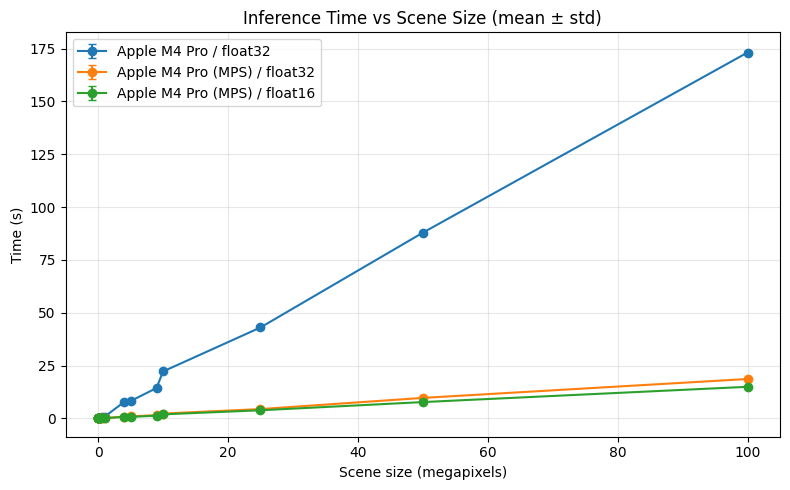

In [5]:
import matplotlib.pyplot as plt

# Build device name mapping for legends
device_names: dict[str, str] = {"cpu": get_cpu_name()}
if torch.cuda.is_available():
    device_names["cuda"] = torch.cuda.get_device_name(0)
if torch.backends.mps.is_available():
    device_names["mps"] = get_mps_gpu_name()

fig, ax = plt.subplots(figsize=(8, 5))

for key, data in results.items():
    device, dtype = key
    dtype_name = str(dtype).split(".")[-1]
    hw_name = device_names.get(device, device)
    label = f"{hw_name} / {dtype_name}"
    megapixels = [r[0] ** 2 / 1e6 for r in data]
    mean_times = [r[1] for r in data]
    std_times = [r[2] for r in data]
    ax.errorbar(
        megapixels, mean_times, yerr=std_times, fmt="o-", label=label, capsize=3
    )

ax.set_xlabel("Scene size (megapixels)")
ax.set_ylabel("Time (s)")
ax.set_title("Inference Time vs Scene Size (mean ± std)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Export results

Save the machine fingerprint and all benchmark results to a JSON file. The filename includes the CPU/GPU name and timestamp so results from different platforms can be collected in a `benchmarks/results/` directory for comparison.

In [6]:
import json
import re
from pathlib import Path

# Build export structure
export: dict = {
    "fingerprint": fingerprint,
    "settings": {
        "repeats_small": REPEATS_SMALL,
        "repeats_large": REPEATS_LARGE,
        "bs_search_repeats": BS_SEARCH_REPEATS,
    },
    "results": [],
}

cpu_baseline = {r[0]: r[1] for r in results.get(("cpu", torch.float32), [])}

for (device, dtype), data in results.items():
    dtype_name = str(dtype).split(".")[-1]
    for size, mean_s, std_s, bs in data:
        entry: dict = {
            "device": device,
            "dtype": dtype_name,
            "scene_size": size,
            "batch_size": bs,
            "mean_seconds": round(mean_s, 4),
            "std_seconds": round(std_s, 4),
        }
        if device != "cpu" and size in cpu_baseline:
            entry["speedup_vs_cpu"] = round(cpu_baseline[size] / mean_s, 2)
        export["results"].append(entry)

# Generate a filename from the primary hardware
hw_tag = fingerprint.get("gpu", fingerprint["cpu"])
hw_tag = re.sub(r"[^\w]+", "_", hw_tag).strip("_").lower()
ts = datetime.now(timezone.utc).strftime("%Y%m%d")
out_dir = Path.cwd() / "results"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / f"{hw_tag}_{ts}.json"

out_path.write_text(json.dumps(export, indent=2) + "\n")
print(f"Saved: {out_path}")
print(f"  {len(export['results'])} result rows across {len(results)} configurations")

Saved: /Users/nick/Documents/Work Code/OmniCloudMask/benchmarking/results/apple_m4_pro_mps_20260328.json
  45 result rows across 3 configurations
